# --- Exploratory Data Analysis --- 


# Part B – Q1.2: Exploratory Data Analysis (EDA)
**Dataset:** IMDB Dataset of 50,000 Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Dataset Overview

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('IMDB Dataset.csv')

# Encode sentiment as numeric label for later use
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("=" * 45)
print("         DATASET Overview")
print("=" * 45)
print(f"  Total reviews    : {len(df):,}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print("=" * 45)
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 3 rows:")
df.head(3)


         DATASET Overview
  Total reviews    : 49,582
  Columns          : ['review', 'sentiment', 'label']
  Missing values   : 0
  Duplicate rows   : 0

Data Types:
review         str
sentiment      str
label        int64
dtype: object

First 3 rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


## 2. Class Distribution

Sentiment Distribution:
  Positive : 24,884  (50.2%)
  Negative : 24,698  (49.8%)


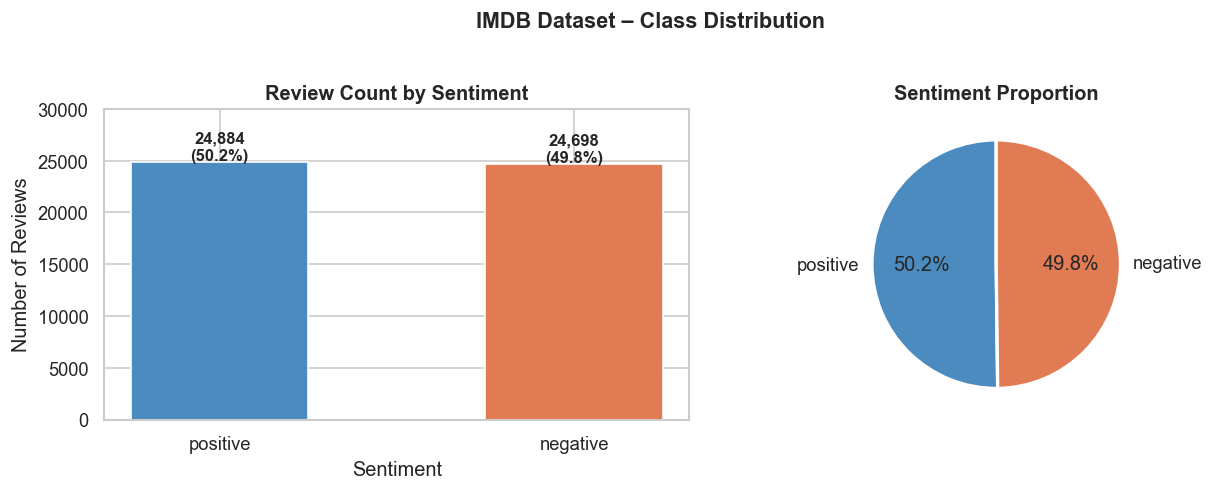

In [3]:
# ── Class distribution ────────────────────────────────────────────────────────
counts = df['sentiment'].value_counts()
pcts   = df['sentiment'].value_counts(normalize=True) * 100

print("Sentiment Distribution:")
print(f"  Positive : {counts['positive']:,}  ({pcts['positive']:.1f}%)")
print(f"  Negative : {counts['negative']:,}  ({pcts['negative']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#4C8BBF', '#E07B54']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Review Count by Sentiment', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Sentiment')
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{bar.get_height():,}\n({pct:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 30000)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Proportion', fontweight='bold')

plt.suptitle('IMDB Dataset – Class Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Review Length Analysis

Review Length Statistics (Word Count):
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   24698.0  229.6  165.1   4.0  128.0  174.0  278.0  1522.0
positive   24884.0  233.1  177.7  10.0  125.0  172.0  284.0  2470.0


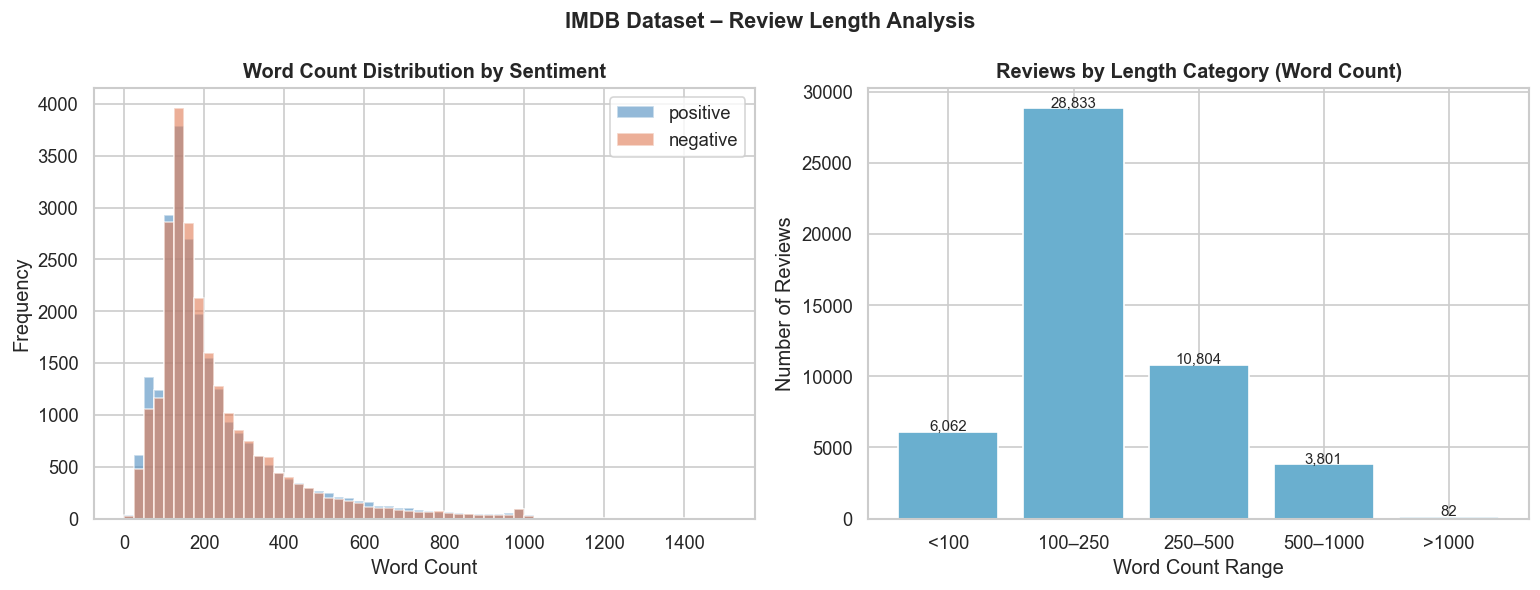

In [4]:
# ── Compute review lengths ────────────────────────────────────────────────────
df['word_count'] = df['review'].str.split().str.len()

print("Review Length Statistics (Word Count):")
print(df.groupby('sentiment')['word_count'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Word count histogram by sentiment
for label, color in zip(['positive', 'negative'], ['#4C8BBF', '#E07B54']):
    subset = df[df['sentiment'] == label]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=label, range=(0, 1500))
axes[0].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review length buckets
bins   = [0, 100, 250, 500, 1000, df['word_count'].max()]
labels = ['<100', '100–250', '250–500', '500–1000', '>1000']
df['length_bucket'] = pd.cut(df['word_count'], bins=bins, labels=labels)
bucket_counts = df['length_bucket'].value_counts().sort_index()
axes[1].bar(bucket_counts.index, bucket_counts.values, color='#6AAFCF', edgecolor='white')
axes[1].set_title('Reviews by Length Category (Word Count)', fontweight='bold')
axes[1].set_xlabel('Word Count Range')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('IMDB Dataset – Review Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Vocabulary & Descriptive Statistics

Descriptive Statistics Summary:
           word_count  unique_words  lexical_richness
sentiment                                            
negative       229.60        139.48              0.66
positive       233.09        139.38              0.65


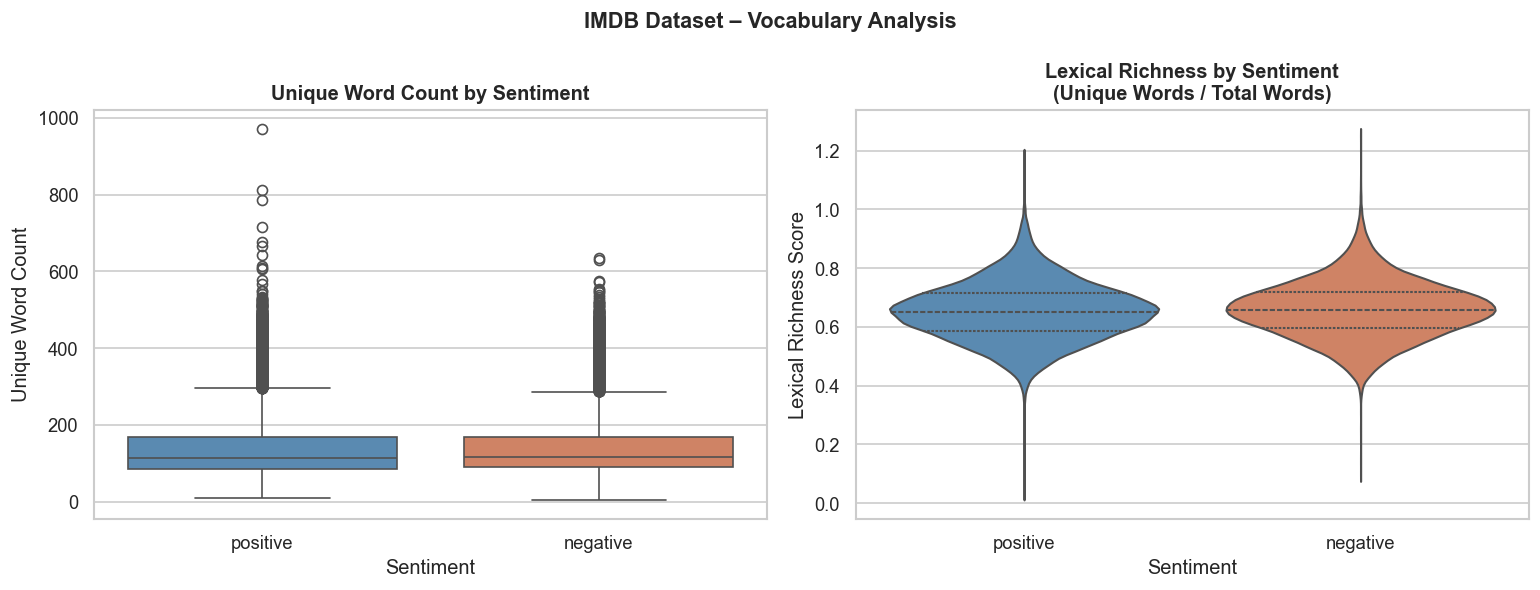

In [5]:
# ── Unique word count per review ──────────────────────────────────────────────
df['unique_words'] = df['review'].apply(
    lambda x: len(set(re.sub(r'[^a-zA-Z]', ' ', x).lower().split()))
)

# ── Lexical richness = unique words / total words ─────────────────────────────
df['lexical_richness'] = df['unique_words'] / df['word_count']

print("Descriptive Statistics Summary:")
stats = df.groupby('sentiment')[['word_count', 'unique_words', 'lexical_richness']].mean().round(2)
print(stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Unique words boxplot
sns.boxplot(data=df, x='sentiment', y='unique_words',
            palette={'positive': '#4C8BBF', 'negative': '#E07B54'}, ax=axes[0])
axes[0].set_title('Unique Word Count by Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Unique Word Count')

# Lexical richness violin
sns.violinplot(data=df, x='sentiment', y='lexical_richness',
               palette={'positive': '#4C8BBF', 'negative': '#E07B54'},
               inner='quartile', ax=axes[1])
axes[1].set_title('Lexical Richness by Sentiment\n(Unique Words / Total Words)', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Lexical Richness Score')

plt.suptitle('IMDB Dataset – Vocabulary Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_vocabulary.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. EDA Summary & Key Findings

In [6]:
# ── Print consolidated EDA summary ───────────────────────────────────────────
print("=" * 55)
print("             EDA SUMMARY – IMDB DATASET")
print("=" * 55)
print(f"  Total reviews          : {len(df):,}")
print(f"  Positive reviews       : {(df['sentiment']=='positive').sum():,} (50%)")
print(f"  Negative reviews       : {(df['sentiment']=='negative').sum():,} (50%)")
print(f"  Missing values         : {df[['review','sentiment']].isnull().sum().sum()}")
print(f"  Duplicate rows         : {df.duplicated(subset=['review']).sum()}")
print()
print("  --- Review Length (Word Count) ---")
print(f"  Overall mean           : {df['word_count'].mean():.1f} words")
print(f"  Overall median         : {df['word_count'].median():.1f} words")
print(f"  Min / Max              : {df['word_count'].min()} / {df['word_count'].max()}")
print()
print("  --- Per Sentiment (Mean Word Count) ---")
for s in ['positive', 'negative']:
    m = df[df['sentiment']==s]['word_count'].mean()
    print(f"  {s.capitalize():<12}         : {m:.1f} words")
print()
print("  --- Vocabulary ---")
print(f"  Avg unique words/review: {df['unique_words'].mean():.1f}")
print(f"  Avg lexical richness   : {df['lexical_richness'].mean():.3f}")




             EDA SUMMARY – IMDB DATASET
  Total reviews          : 49,582
  Positive reviews       : 24,884 (50%)
  Negative reviews       : 24,698 (50%)
  Missing values         : 0
  Duplicate rows         : 0

  --- Review Length (Word Count) ---
  Overall mean           : 231.4 words
  Overall median         : 173.0 words
  Min / Max              : 4 / 2470

  --- Per Sentiment (Mean Word Count) ---
  Positive             : 233.1 words
  Negative             : 229.6 words

  --- Vocabulary ---
  Avg unique words/review: 139.4
  Avg lexical richness   : 0.657


# --- Pre-processing --- 


## Data Pre-Processing

In [7]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd

In [8]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('IMDB Dataset.csv')

# Encode sentiment as numeric label for later use
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("=" * 45)
print("         DATASET Overview")
print("=" * 45)
print(f"  Total reviews    : {len(df):,}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print("=" * 45)
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 3 rows:")
df.head(3)


         DATASET Overview
  Total reviews    : 49,582
  Columns          : ['review', 'sentiment', 'label']
  Missing values   : 0
  Duplicate rows   : 0

Data Types:
review         str
sentiment      str
label        int64
dtype: object

First 3 rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [9]:
# ── Remove duplicate reviews ──────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['review'])
after = len(df)

print(f"Rows before        : {before:,}")
print(f"Rows after         : {after:,}")
print(f"Duplicates removed : {before - after:,}")

# ── Overwrite original dataset with cleaned version ───────────────────────────
df.to_csv('IMDB Dataset.csv', index=False)
print(f"Saved {len(df):,} rows to 'IMDB Dataset.csv'")

Rows before        : 49,582
Rows after         : 49,582
Duplicates removed : 0
Saved 49,582 rows to 'IMDB Dataset.csv'


In [10]:
# ── Pre-Processed Dataset ───────────────────────────────────────────────────
print("Missing values:")
print(df.isnull().sum())
print()
print(f"Remaining duplicates : {df.duplicated(subset=['review']).sum()}")
print(f"Total rows remaining : {len(df):,}")

Missing values:
review       0
sentiment    0
label        0
dtype: int64

Remaining duplicates : 0
Total rows remaining : 49,582


# --- SVM Model --- 


# Part B – Sarvein: Supervised Text Classification (SVM Model)

**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`  
**Model:** Support Vector Machine (SVM) with TF-IDF features


In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Download required NLTK data
nltk.download('stopwords', quiet=True)



True

In [12]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Ensure 'IMDB Dataset.csv' is in the same directory as this notebook
df = pd.read_csv('IMDB Dataset.csv')

# Encode label: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape  : {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
df.head(3)


Dataset shape  : (49582, 3)

Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [13]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Lowercase and tokenise
    tokens = text.lower().split()
    # 4 & 5. Remove stop words and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)


df['clean_review'] = df['review'].apply(clean_text)
print(f"Done. Sample cleaned review:\n\n{df['clean_review'].iloc[0][:300]}")


Done. Sample cleaned review:

one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e


In [14]:
# ── Train/Test Split & TF-IDF Vectorisation ───────────────────────────────────
X = df['clean_review']
y = df['label']

# 80/20 stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: convert text to numerical feature matrix
# max_features=40000 adjusted for cleaned dataset size
# ngram_range=(1,2) includes unigrams and bigrams
tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on training data only
X_test_tfidf  = tfidf.transform(X_test)         # transform test data

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")

Training samples : 39665
Test samples     : 9917
TF-IDF features  : 40000


In [15]:
# ── Build & Train SVM Model ───────────────────────────────────────────────────

svm_model = LinearSVC(C=1.0, max_iter=1000, random_state=42)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully.")


SVM model trained successfully.


In [16]:
# ── Model Evaluation ─────────────────────────────────────────────────────────
y_pred = svm_model.predict(X_test_tfidf)

# Compute evaluation metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("         SVM MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


         SVM MODEL EVALUATION RESULTS
  Accuracy  : 0.9002  (90.02%)
  Precision : 0.8977
  Recall    : 0.9042
  F1-Score  : 0.9009

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      4940
    Positive       0.90      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



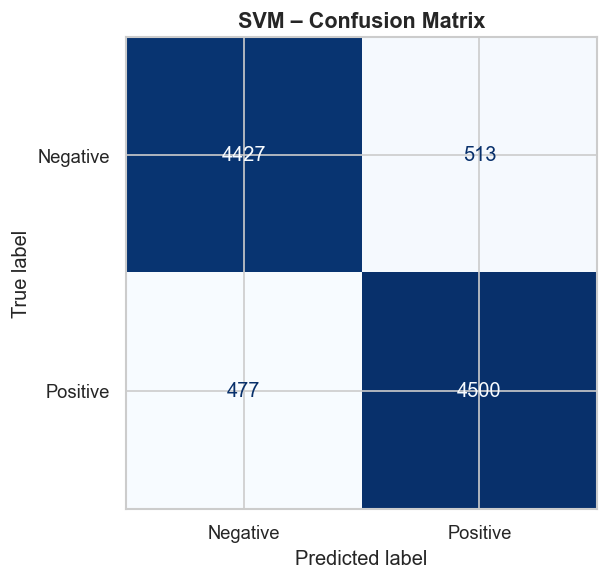

In [17]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM – Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



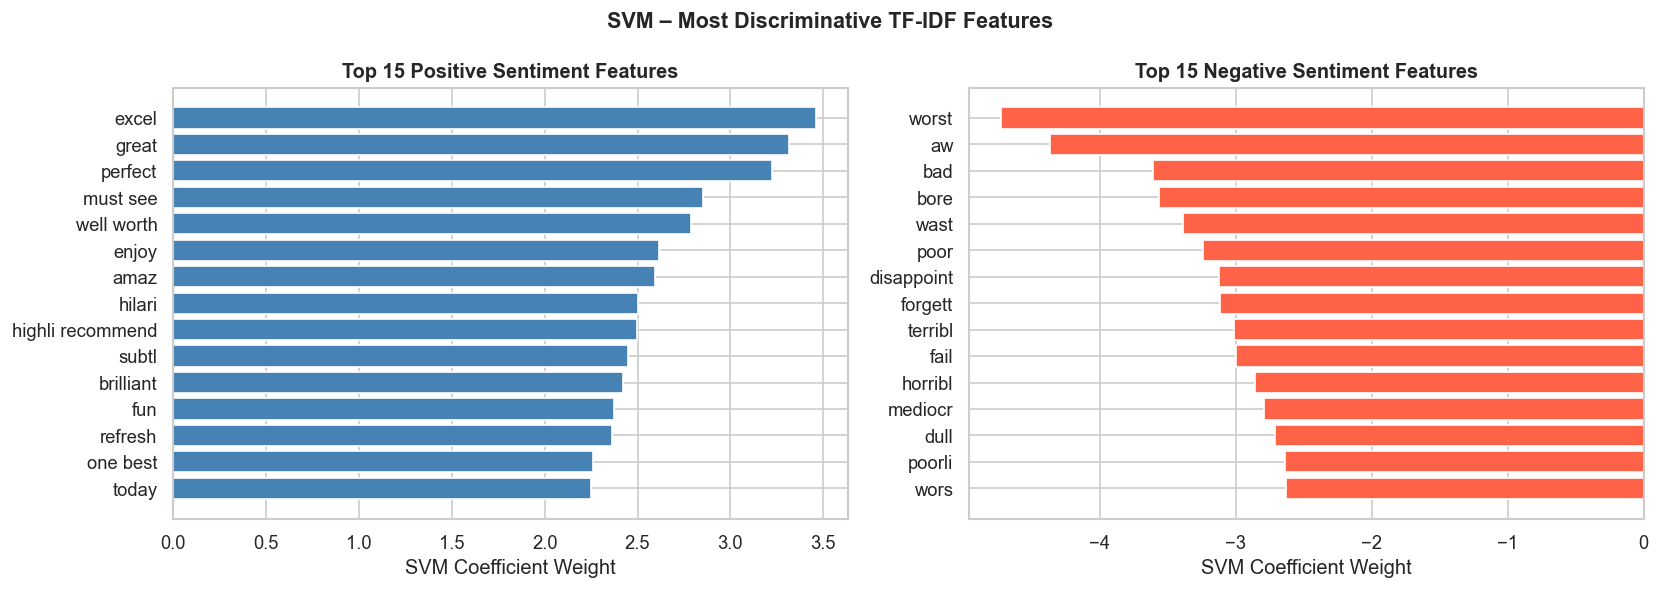

In [18]:
# ── Top Discriminative Features ───────────────────────────────────────────────
# Positive weights: associated with positive sentiment
# Negative weights: associated with negative sentiment

feature_names = tfidf.get_feature_names_out()
coef = svm_model.coef_[0]

top_n = 15
top_pos_idx = coef.argsort()[-top_n:][::-1]   # highest weights
top_neg_idx = coef.argsort()[:top_n]           # lowest (most negative) weights

top_pos_words   = [feature_names[i] for i in top_pos_idx]
top_pos_weights = [coef[i] for i in top_pos_idx]
top_neg_words   = [feature_names[i] for i in top_neg_idx]
top_neg_weights = [coef[i] for i in top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos_words[::-1], top_pos_weights[::-1], color='steelblue')
axes[0].set_title('Top 15 Positive Sentiment Features', fontweight='bold')
axes[0].set_xlabel('SVM Coefficient Weight')

axes[1].barh(top_neg_words[::-1], top_neg_weights[::-1], color='tomato')
axes[1].set_title('Top 15 Negative Sentiment Features', fontweight='bold')
axes[1].set_xlabel('SVM Coefficient Weight')

plt.suptitle('SVM – Most Discriminative TF-IDF Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



---
# Part B – Q3: Hyperparameter Tuning (SVM)

GridSearchCV is used to systematically search over a defined parameter grid.  
5-fold cross-validation is applied on the training set for each combination.


In [19]:
# ── GridSearchCV ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {
    'C'        : [0.01, 0.1, 1.0, 10.0],
    'loss'     : ['hinge', 'squared_hinge'],
    'max_iter' : [500, 1000]
}

# Initialise the base estimator
svm_base = LinearSVC(random_state=42)

# GridSearchCV with 5-fold cross-validation, scoring on F1 (macro)
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(
    estimator  = svm_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("Running GridSearchCV over the following grid:")
print(param_grid)

grid_search.fit(X_train_tfidf, y_train)

print("\nGridSearchCV complete.")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")


Running GridSearchCV over the following grid:
{'C': [0.01, 0.1, 1.0, 10.0], 'loss': ['hinge', 'squared_hinge'], 'max_iter': [500, 1000]}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

GridSearchCV complete.
Best Parameters : {'C': 1.0, 'loss': 'hinge', 'max_iter': 500}
Best CV F1 Score: 0.8999


In [20]:
# ── Evaluate Best Tuned SVM on Test Set ───────────────────────────────────────
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_tfidf)

acc_t   = accuracy_score(y_test, y_pred_tuned)
prec_t  = precision_score(y_test, y_pred_tuned)
rec_t   = recall_score(y_test, y_pred_tuned)
f1_t    = f1_score(y_test, y_pred_tuned)

print("=" * 50)
print("     TUNED SVM MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc_t:.4f}  ({acc_t*100:.2f}%)")
print(f"  Precision : {prec_t:.4f}")
print(f"  Recall    : {rec_t:.4f}")
print(f"  F1-Score  : {f1_t:.4f}")
print("=" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))


     TUNED SVM MODEL EVALUATION RESULTS
  Accuracy  : 0.9017  (90.17%)
  Precision : 0.8950
  Recall    : 0.9110
  F1-Score  : 0.9029

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



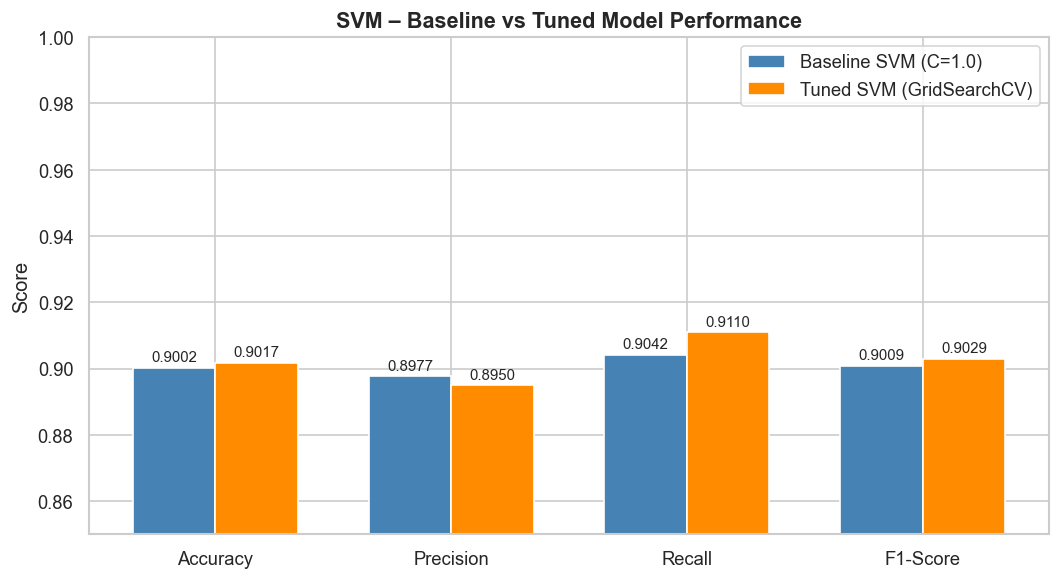

In [21]:
# ── Before vs After Tuning Comparison ────────────────────────────────────────
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [acc,   precision, recall, f1]
tuned_vals    = [acc_t, prec_t,    rec_t,  f1_t]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline SVM (C=1.0)',  color='steelblue')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned SVM (GridSearchCV)', color='darkorange')

ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('SVM – Baseline vs Tuned Model Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Annotate bars with exact values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



In [ ]:
# ===============================
# Random Forest Model (Added after Sarvein's SVM section)
# Covers:
# Q2.1 Build supervised model
# Q2.2 Evaluation measures + results
# Q2.3 Hyper-parameter selection and GridSearchCV tuning
# Critical analysis of results
# ===============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Reuse processed text and split created earlier in Sarvein's part:
# X_train, X_test, y_train, y_test come from clean_review preprocessing.

print('=' * 80)
print('RANDOM FOREST SECTION (USING PROCESSED DATASET)')
print('=' * 80)

# -------------------------------
# 1) Feature Preparation
# -------------------------------
# Random Forest is computationally expensive with very high-dimensional sparse text,
# so we use a compact TF-IDF feature space.
rf_tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_rf = rf_tfidf.fit_transform(X_train)
X_test_rf  = rf_tfidf.transform(X_test)

print(f'Training samples : {X_train_rf.shape[0]}')
print(f'Test samples     : {X_test_rf.shape[0]}')
print(f'TF-IDF features  : {X_train_rf.shape[1]}')

# -------------------------------
# 2) Build Baseline Random Forest (Q2.1)
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train)
print('\nBaseline Random Forest trained successfully.')

# -------------------------------
# 3) Evaluation Measures (Q2.2)
# -------------------------------
print('\nEvaluation measures used:')
print('- Accuracy  : Overall proportion of correct predictions')
print('- Precision : Correct positive predictions / all predicted positives')
print('- Recall    : Correct positive predictions / all actual positives')
print('- F1-Score  : Harmonic mean of precision and recall')

y_pred_rf = rf_model.predict(X_test_rf)

rf_acc       = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall    = recall_score(y_test, y_pred_rf)
rf_f1        = f1_score(y_test, y_pred_rf)

print('\n' + '=' * 56)
print('BASELINE RANDOM FOREST EVALUATION RESULTS')
print('=' * 56)
print(f'Accuracy  : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'Precision : {rf_precision:.4f}')
print(f'Recall    : {rf_recall:.4f}')
print(f'F1-Score  : {rf_f1:.4f}')
print('=' * 56)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))

# Confusion matrix (baseline)
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Negative', 'Positive']).plot(cmap='Blues', ax=ax)
ax.set_title('Random Forest - Confusion Matrix (Baseline)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------
# 4) Hyper-Parameter Selection (Q2.3.1)
# -------------------------------
print('\nSelected hyper-parameters for tuning and why:')
print('- n_estimators      : controls number of trees (stability vs runtime)')
print('- max_depth         : controls tree complexity / overfitting')
print('- min_samples_split : controls splitting aggressiveness')
print('- min_samples_leaf  : smooths leaves to reduce variance')
print('- max_features      : controls randomness and tree diversity')

# -------------------------------
# 5) GridSearchCV Tuning (Q2.3.2)
# -------------------------------
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print('\nRunning GridSearchCV for Random Forest...')
print(rf_param_grid)
rf_grid.fit(X_train_rf, y_train)

print('\nGridSearchCV complete.')
print(f'Best Parameters : {rf_grid.best_params_}')
print(f'Best CV F1 Score: {rf_grid.best_score_:.4f}')

# Evaluate tuned model
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_rf)

rf_acc_t   = accuracy_score(y_test, y_pred_rf_tuned)
rf_prec_t  = precision_score(y_test, y_pred_rf_tuned)
rf_rec_t   = recall_score(y_test, y_pred_rf_tuned)
rf_f1_t    = f1_score(y_test, y_pred_rf_tuned)

print('\n' + '=' * 56)
print('TUNED RANDOM FOREST EVALUATION RESULTS')
print('=' * 56)
print(f'Accuracy  : {rf_acc_t:.4f}  ({rf_acc_t*100:.2f}%)')
print(f'Precision : {rf_prec_t:.4f}')
print(f'Recall    : {rf_rec_t:.4f}')
print(f'F1-Score  : {rf_f1_t:.4f}')
print('=' * 56)
print('\nDetailed Classification Report (Tuned):')
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Negative', 'Positive']))

# Comparison table and chart
rf_results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline RF': [rf_acc, rf_precision, rf_recall, rf_f1],
    'Tuned RF': [rf_acc_t, rf_prec_t, rf_rec_t, rf_f1_t]
})

print('\nBaseline vs Tuned Random Forest:')
print(rf_results_df.to_string(index=False, formatters={'Baseline RF': '{:.4f}'.format, 'Tuned RF': '{:.4f}'.format}))

x = np.arange(len(rf_results_df['Metric']))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bar1 = ax.bar(x - width/2, rf_results_df['Baseline RF'], width, label='Baseline RF', color='steelblue')
bar2 = ax.bar(x + width/2, rf_results_df['Tuned RF'], width, label='Tuned RF (GridSearchCV)', color='darkorange')

ax.set_ylim(0.80, 1.00)
ax.set_ylabel('Score')
ax.set_title('Random Forest - Baseline vs Tuned Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(rf_results_df['Metric'])
ax.legend()

for bar in list(bar1) + list(bar2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# -------------------------------
# 6) Critical Analysis
# -------------------------------
print('\nCritical analysis summary:')
if rf_f1_t >= rf_f1:
    print('- Tuning improved (or maintained) F1-score, indicating better bias-variance trade-off.')
else:
    print('- Tuning did not improve F1-score; the baseline may already be near optimal for this feature setup.')

if rf_prec_t > rf_rec_t:
    print('- Precision > Recall: model is more conservative for positive predictions.')
elif rf_prec_t < rf_rec_t:
    print('- Recall > Precision: model captures more positives but may increase false positives.')
else:
    print('- Precision and Recall are balanced.')

print('- Random Forest is robust, but sparse high-dimensional text often favours linear classifiers like SVM.')
print('- Further gains can come from feature selection, threshold tuning, or transformer-based representations.')